# Flipkart AC Market Analysis: Web Scraping & EDA

## 🎯 Project Objective:

- In the role of a Data Analyst, this project focuses on analyzing Air Conditioner (AC) listings data from Flipkart to understand pricing patterns, product preferences, and market trends.

## Primary Goals:

- Identify key factors influencing AC prices (brand, tonnage, star rating, features)

- Understand customer preferences in terms of energy efficiency, capacity, and pricing

- Analyze relationships between price, brand, tonnage, and star ratings

- Detect market segmentation between budget, mid-range, and premium ACs

- Provide insights that help understand demand patterns and seller strategies

- Support better product positioning and decision-making for buyers and sellers

# Import Libraries

In [7]:
# importing libraries needed for scraping and analysis

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re

# Headers and Empty Lists

In [8]:
# adding headers so the website treats the request like a normal browser visit

headers = {
    "content-type":"text/plain",
    "user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36",
    "accept-encoding":"gzip, deflate, br, zstd"
}

# creating empty lists to store scraped product details

prod_name = []
prod_rating = []
prod_costprice = []
prod_originalprice = []
prod_discount = []
prod_reviews = []
prod_features = []
page_num = []

# Web Scraping

In [ ]:
# starting timer to track total scraping time

total_time = time.time()

# looping through multiple pages to collect product data

for i in range(1,38):
    
    # tracking time taken for each page
    
    start_time = time.time()

    # generating page url dynamically
    
    url = f"https://www.flipkart.com/search?q=ac&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"

    # sending request to website
    
    try:
       response = requests.get(url, headers=headers, timeout=10)
       response.raise_for_status()
    
    except requests.exceptions.RequestException as e:
       print(f"Page {i} failed: {e}")
       continue

    # parsing webpage content using BeautifulSoup
    
    soup = BeautifulSoup(response.text, "html.parser")

    # finding all product sections available on the page
    
    for x in soup.find_all("div", attrs={"class":"jIjQ8S"}):

        # extracting product name
        
        name = x.find("div", attrs={"class":"RG5Slk"})

        # extracting product rating
        
        rating = x.find("div", attrs={"class":"MKiFS6"})

        # extracting current selling price
        
        costprice = x.find("div", attrs={"class":"hZ3P6w DeU9vF"})

        # extracting original price
        
        originalprice = x.find("div", attrs={"class":"kRYCnD gxR4EY"})

        # extracting product discount
        
        discount = x.find("div", attrs={"class":"HQe8jr"})

        # extracting customer reviews
        
        reviews = x.find("span", attrs={"class":"PvbNMB"})

        # extracting product specifications and features
        
        features = x.find("div", attrs={"class":"CMXw7N"})

        # storing extracted values into lists
        
        prod_name.append(name.text if name else np.nan)
        prod_rating.append(rating.text if rating else np.nan)
        prod_costprice.append(costprice.text if costprice else np.nan)
        prod_originalprice.append(originalprice.text if originalprice else np.nan)
        prod_discount.append(discount.text if discount else np.nan)
        prod_reviews.append(reviews.text if reviews else np.nan)
        prod_features.append(features.text if features else np.nan)
        page_num.append(i)

    # printing time taken for current page
    
    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')

    # adding small delay between requests
    
    time.sleep(np.random.randint(3,5))

# total scraping completed

print("Total Time Completed in seconds", str(time.time()-total_time))

Page 1 completed in 1.17 seconds
Page 2 completed in 1.34 seconds
Page 3 completed in 1.13 seconds
Page 4 completed in 0.96 seconds
Page 5 completed in 3.32 seconds
Page 6 completed in 1.39 seconds
Page 7 completed in 0.95 seconds
Page 8 completed in 1.34 seconds
Page 9 completed in 1.75 seconds
Page 10 completed in 2.00 seconds
Page 11 completed in 1.18 seconds
Page 12 completed in 2.56 seconds
Page 13 completed in 2.70 seconds
Page 14 completed in 1.45 seconds
Page 15 completed in 1.14 seconds
Page 16 completed in 2.59 seconds
Page 17 completed in 1.72 seconds
Page 18 completed in 1.21 seconds
Page 19 completed in 1.18 seconds
Page 20 completed in 1.24 seconds
Page 21 completed in 1.50 seconds
Page 22 completed in 2.16 seconds
Page 23 completed in 1.80 seconds
Page 24 completed in 2.12 seconds
Page 25 completed in 2.14 seconds
Page 26 completed in 1.70 seconds
Page 27 completed in 2.30 seconds
Page 28 completed in 1.77 seconds
Page 29 completed in 1.56 seconds
Page 30 completed in 1.

# Create DataFrame

In [10]:
# creating dataframe from scraped data

df = pd.DataFrame({
    "ProductName": prod_name,
    "Rating": prod_rating,
    "Price": prod_costprice,
    "OriginalPrice": prod_originalprice,
    "Discount": prod_discount,
    "Reviews": prod_reviews,
    "Features": prod_features,
    "PageNumber": page_num
})

# Save CSV File

In [13]:
# saving raw scraped data into csv file

df.to_csv("data/raw.csv", index=False)

# Loading the dataset

In [14]:
df = pd.read_csv("data/raw.csv")

# Dataset Overview

In [15]:
# checking dataset structure and sample records

df.head()

,ProductName,Rating,Price,OriginalPrice,Discount,Reviews,Features,PageNumber
0,TCL 2026 Model 1 Ton 3 Star Split Inverter 7 S...,3.8,"₹24,990","₹48,991",48% off,827 Ratings & 110 Reviews,Annual Power Usage: 596.47 kWhRoom Size: 90 sq...,1
1,Samsung 2025 Model 1.5 Ton 5 Star Split Invert...,4.2,"₹36,490","₹72,990",50% off,"26,515 Ratings & 2,683 Reviews",Annual Power Usage: 751.24 WRoom Size: 111 - 1...,1
2,MarQ by Flipkart 2026 Model 1 Ton 3 Star Split...,4.2,"₹21,990","₹47,999",54% off,"43,706 Ratings & 5,407 Reviews",Annual Power Usage: 594.03 kWhRoom Size: 90 sq...,1
3,MarQ by Flipkart 2026 Model 1.5 Ton 3 Star Spl...,4.2,"₹26,490","₹49,999",47% off,"49,936 Ratings & 6,373 Reviews",Annual Power Usage: 858.22 kWhRoom Size: 111 -...,1
4,Daikin 2026 Model 1.5 Ton 3 Star Split Inverte...,4.2,"₹37,490","₹56,100",33% off,"24,785 Ratings & 1,912 Reviews",Annual Power Usage: 880.1 kWhRoom Size: 111 - ...,1


In [16]:
df.shape

(888, 8)

# Understanding Column Information

In [17]:
# displaying all column names

df.columns

Index(['ProductName', 'Rating', 'Price', 'OriginalPrice', 'Discount',
       'Reviews', 'Features', 'PageNumber'],
      dtype='str')

# Checking Data Types

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 888 entries, 0 to 887
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ProductName    888 non-null    str    
 1   Rating         856 non-null    float64
 2   Price          888 non-null    str    
 3   OriginalPrice  871 non-null    str    
 4   Discount       868 non-null    str    
 5   Reviews        856 non-null    str    
 6   Features       886 non-null    str    
 7   PageNumber     888 non-null    int64  
dtypes: float64(1), int64(1), str(6)
memory usage: 55.6 KB


## Statistical Summary

In [19]:
# generating statistical summary for numerical columns

df.describe()

,Rating,PageNumber
count,856.000000,888.000000
mean,4.069393,19.000000
std,0.211201,10.683095
min,1.800000,1.000000
25%,4.000000,10.000000
50%,4.100000,19.000000
75%,4.200000,28.000000
max,5.000000,37.000000


## Identifying Missing Values

In [20]:
# checking missing values in dataset

df.isnull().sum()

ProductName       0
Rating           32
Price             0
OriginalPrice    17
Discount         20
Reviews          32
Features          2
PageNumber        0
dtype: int64

## Observation

- Here we can see that Rating, OriginalPrice, Discount, and Reviews columns contain some null values.

- Since the number of missing values is very small compared to the total dataset size (less than 5%), dropping these rows will not significantly affect the analysis.

- So, we can safely remove these null values during the data cleaning process.

# Checking Duplicate Records

In [21]:
# checking duplicate records

df.duplicated().sum()

np.int64(3)

# Data Cleaning

## Dropping Missing Values

In [23]:
# dropping rows with missing values

df.dropna(inplace=True)

## Checking Again for Verification

In [24]:
# verifying whether null values are removed

df.isnull().sum()

ProductName      0
Rating           0
Price            0
OriginalPrice    0
Discount         0
Reviews          0
Features         0
PageNumber       0
dtype: int64

## Observation

- As we can see, there are no null values present in the dataset after the cleaning process.

- The dataset is now cleaner and ready for further preprocessing and visualization.

## Removing Duplicate Records

In [26]:
# removing duplicate records from dataset

df.drop_duplicates(inplace=True)

## Checking Again for Verification

In [27]:
# verifying whether duplicate records are removed

df.duplicated().sum()

np.int64(0)

## Observation

- As we can see, there are no duplicate records present in the dataset after the cleaning process.

- The dataset is now cleaner and ready for further analysis and visualization.

## Cleaning Price Column

In [28]:
# removing currency symbols and commas from price column

df["Price"] = df["Price"].str.replace("₹", "")
df["Price"] = df["Price"].str.replace(",", "")

## Cleaning Original Price Column

In [29]:
# cleaning original price column

df["OriginalPrice"] = df["OriginalPrice"].str.replace("₹", "")
df["OriginalPrice"] = df["OriginalPrice"].str.replace(",", "")

## Cleaning Discount Column

In [30]:
# removing percentage symbol from discount column

df["Discount"] = df["Discount"].str.replace("% off", "")

## Datatype Conversion

In [31]:
# converting columns into numeric datatype

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["OriginalPrice"] = pd.to_numeric(df["OriginalPrice"], errors="coerce")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Discount"]= pd.to_numeric(df["Discount"],errors="coerce")

## Splitting Ratings and Reviews Column

In [32]:
# splitting ratings and reviews into separate columns

df["Ratings1"] = df["Reviews"].apply(lambda x: re.split(r"[&]", x)[0])

df["Reviews1"] = df["Reviews"].apply(lambda x: re.split(r"[&]", x)[1])

## Observation

- The Reviews column contains both ratings count and reviews count in a single column.

- Splitting this column into separate columns makes the dataset more structured and easier to analyze.

- The new columns Ratings1 and Reviews1 can now be used independently for further preprocessing and visualization.

## Extracting Numerical Ratings and Reviews

In [33]:
# extracting only numerical values from ratings and reviews columns

df["Number_Ratings"] = df["Ratings1"].apply(lambda x: re.findall(r"[\d,]+", x)[0]).str.replace(",", "").astype("int64")

df["Number_Reviews"] = df["Reviews1"].apply(lambda x: re.findall(r"[\d,]+", x)[0]).str.replace(",", "").astype("int64")

## Observation

- The Ratings1 and Reviews1 columns contain text along with numerical values.

- Using regular expressions, only the numerical part was extracted from both columns.

- The extracted values were converted into integer datatype for numerical analysis and visualization.

- The new columns Number_Ratings and Number_Reviews can now be used for statistical analysis and plotting.

# Feature Engineering

## Extracting Brand Names

In [34]:
# extracting brand names from product titles

df["Brand"] = df["ProductName"].apply(lambda x: re.findall(r"[\w]+", x)[0])

df["Brand"].head()

0        TCL
1    Samsung
2       MarQ
3       MarQ
4     Daikin
Name: Brand, dtype: str

## Observation

- Brand names were successfully extracted from the ProductName column.

- This new column can help in brand-wise analysis and visualization.

## Extracting AC Capacity (Ton)

In [35]:
# extracting AC tonnage from product name

df["Ton"] = df["ProductName"].str.extract(r"(\d+(?:\.\d+)?)\s*Ton")

df["Ton"] = pd.to_numeric(df["Ton"])

## Observation

- AC capacity in tons was extracted successfully from product titles.

- This feature can help analyze pricing and ratings based on AC capacity.

## Extracting Star Ratings

In [36]:
# extracting star rating from product name

df["Star"] = df["ProductName"].str.extract(r"(\d)\s*Star")

df["Star"] = pd.to_numeric(df["Star"])

## Observation

- Energy efficiency star ratings were extracted successfully.

- This feature can help compare energy-efficient products across brands.

## Extracting AC Type

In [37]:
# extracting AC type from product titles

df["AC_Type"] = df["ProductName"].str.extract(r"(Split|Window)")

## Observation

- AC types such as Split and Window were extracted successfully.

- This feature enables category-wise analysis of products.

## Extracting Power Usage

In [38]:
# extracting annual power usage

df["Power_Usage"] = df["Features"].str.extract(r"Annual Power Usage:\s*(\d+\.?\d*)")

df["Power_Usage"] = pd.to_numeric(df["Power_Usage"])

## Observation

- Power consumption values were extracted successfully from the Features column.

- This feature can help analyze energy consumption patterns across different AC models.

## Extracting Room Size

In [39]:
# extracting only room size values

df["Room_Size"] = df["Features"].str.extract(r"Room Size:\s*([\d\s\-\w]+sqft)")

## Observation

- Room size information was extracted successfully from product specifications.

- This feature can help compare AC models based on recommended room coverage area.

## Removing Unnecessary Columns

In [40]:
# removing unnecessary columns after feature extraction

df.drop(columns=["Features","Reviews","Ratings1","Reviews1"],inplace=True)

## Observation

- Original Features and Reviews columns contained unstructured text data.

- After extracting useful information into separate columns, these columns became unnecessary.

- Removing redundant columns helps make the dataset cleaner and easier to analyze.

## Handling Missing Values in Engineered Features

In [41]:
df[["ProductName","Ton","Star","Power_Usage","Room_Size"]].isnull().sum()

ProductName     0
Ton             6
Star            2
Power_Usage    52
Room_Size       4
dtype: int64

## Observation

- A few missing values are present in engineered feature columns.

- These missing values occurred because some products do not contain complete specifications in their descriptions.

- Since the number of missing values is very small, they can be handled using statistical methods.

In [42]:
# filling missing values in engineered columns

df["Ton"] = df["Ton"].fillna(df["Ton"].median())

df["Star"] = df["Star"].fillna(df["Star"].mode()[0])

df["Power_Usage"] = df["Power_Usage"].fillna(df["Power_Usage"].median())

df["Room_Size"] = df["Room_Size"].fillna(df["Room_Size"].mode()[0])

## Observation

- All missing values in engineered feature columns were handled successfully.

- The dataset is now fully cleaned and ready for exploratory data analysis and visualization.

## Checking Again for Verification

In [43]:
# verifying missing values after cleaning

df[["Ton", "Star", "Power_Usage", "Room_Size"]].isnull().sum()

Ton            0
Star           0
Power_Usage    0
Room_Size      0
dtype: int64

## Observation

- All missing values in engineered feature columns were handled successfully.

- The dataset is now fully cleaned and ready for exploratory data analysis and visualization.

## Price Per Ton

In [ ]:
# calculating price per ton to measure value for money

df["Price_Per_Ton"] = df["Price"] / df["Ton"]

## Observation

- Price Per Ton was calculated by dividing the selling price by the AC capacity in tons.

- This new feature helps identify which ACs offer the best value for money.

- Lower price per ton means better cooling capacity at a cheaper cost.

# Saving Cleaned Dataset

In [44]:
# saving cleaned dataset into csv file

df.to_csv("data/cleaned.csv", index=False)

## Observation

- The cleaned and transformed dataset was successfully saved for further analysis and visualization.

- Storing the cleaned dataset separately helps maintain a proper data workflow and improves project organization.

# Exploratory Data Analysis and Visualization

# Univariate Analysis

## Brand Distribution

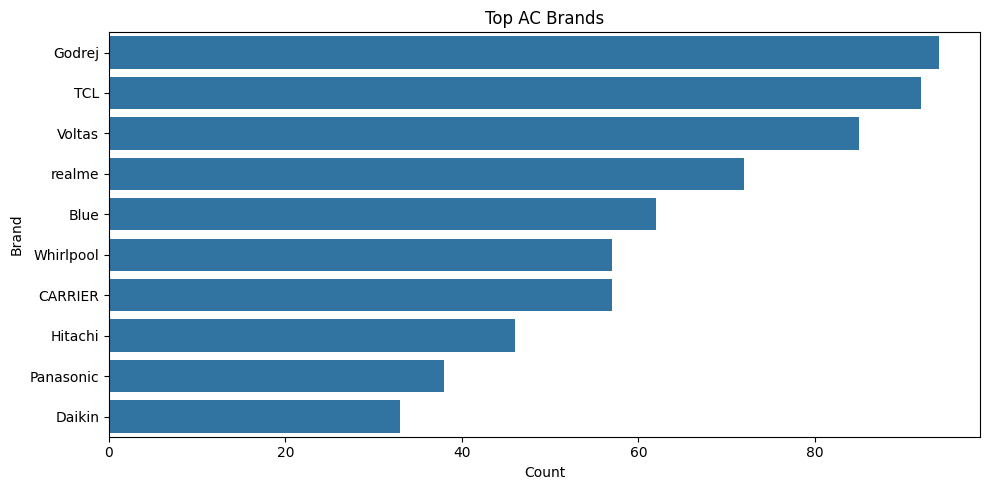

In [45]:
# visualizing top AC brands

plt.figure(figsize=(10,5))
sns.countplot(y="Brand",data=df,order=df["Brand"].value_counts().index[:10])
plt.title("Top AC Brands")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

### Brand Distribution Insights:

- Godrej, Voltas, TCL, and realme are the top listed brands on Flipkart.

- The market is clearly dominated by established brands — smaller brands barely have any presence.

- This shows Flipkart's AC section is a big-brand game with very little room for local players.

## Price Distribution

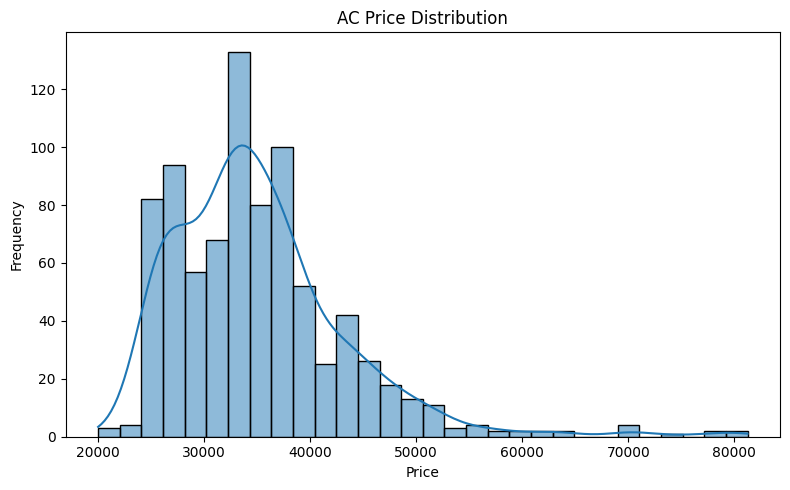

In [46]:
# visualizing price distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("AC Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Price Distribution Insights:

- Most ACs on Flipkart are priced around ₹25,000 to ₹45,000, so basically the platform is mainly focused on middle-class / mid-budget buyers.

- The graph is right-skewed, which just means a few very expensive premium ACs are pushing the price range upward, even though most products are not that costly.

- There are not many cheap AC options, so budget buyers don’t get as many choices compared to mid-range ones.

- Overall, Flipkart is clearly dominated by mid-range ACs, with a small number of premium models sitting at the top end.

## Star Rating Distribution

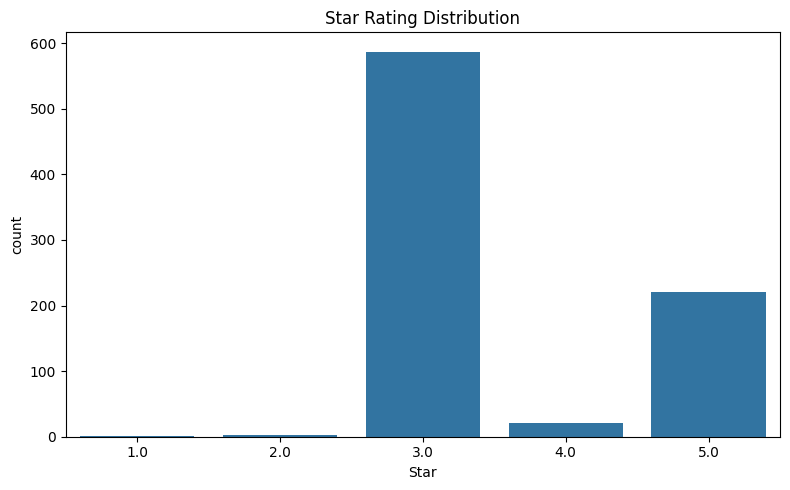

In [47]:
# visualizing star ratings distribution

plt.figure(figsize=(8,5))
sns.countplot(x="Star", data=df)
plt.title("Star Rating Distribution")
plt.tight_layout()
plt.show()

### Star Rating Distribution Insights:

- Most ACs are 3-star and 5-star rated, so these dominate the listings.

- 1-star and 2-star ACs are very few, almost negligible.

- Sellers clearly prefer listing energy-efficient models.

- Overall, the market is tilted towards higher efficiency ACs.

## AC Type Distribution

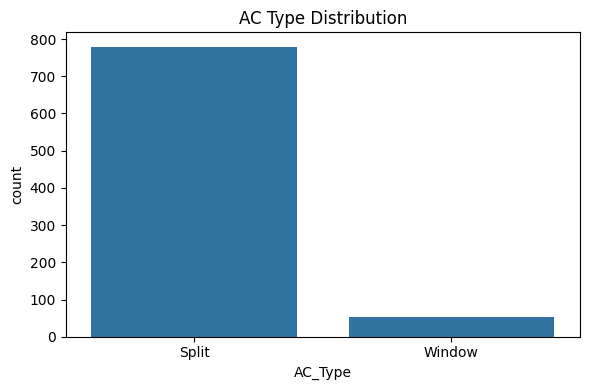

In [48]:
# checking split vs window AC distribution

plt.figure(figsize=(6,4))
sns.countplot(x="AC_Type", data=df)
plt.title("AC Type Distribution")
plt.tight_layout()
plt.show()

### AC Type Distribution Insight:

- Split ACs dominate the listings compared to Window ACs by a huge margin.

- Window ACs are older technology mostly suited for small rooms.

- Most modern homes are designed for Split ACs, which explains the clear preference.

- Sellers on Flipkart are clearly targeting urban buyers who prefer Split ACs.

# Bivariate Analysis

## Brand vs Average Price

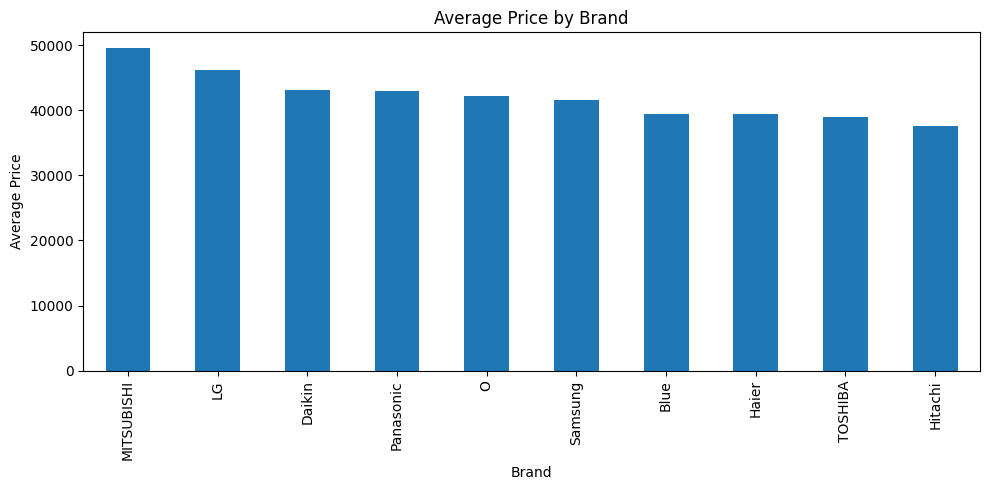

In [49]:
# comparing average prices across brands

brand_price = df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
brand_price.plot(kind="bar")
plt.title("Average Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

### Brand vs Average Price – Insights :

- MITSUBISHI and LG are clearly positioned as premium brands with the highest average prices.

- Daikin and Panasonic strike a balance between quality and affordability, making them popular mid-range choices.

- There is a clear price gap between premium and budget brands, showing distinct market segmentation.

- Budget buyers have fewer brand options compared to mid-range and premium segments.

### Brand vs Price per Ton

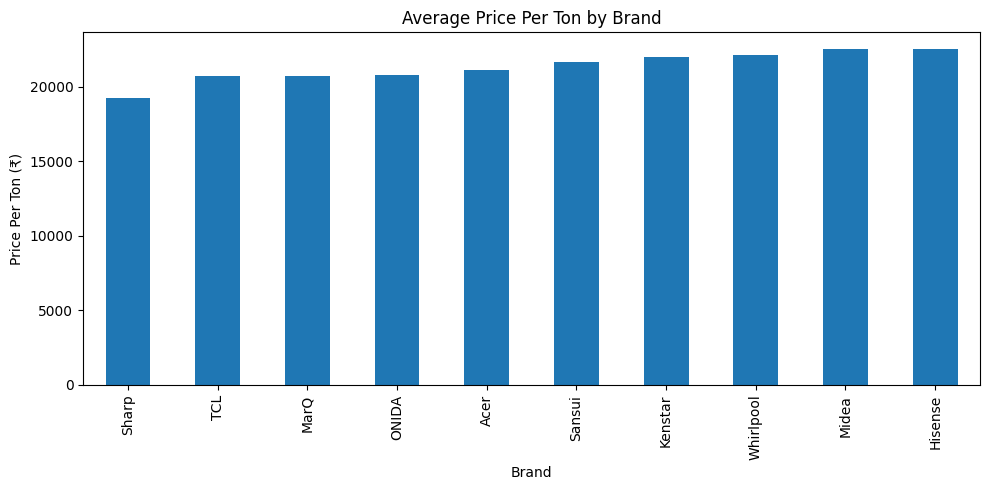

In [58]:
# which brand gives best value per ton
brand_ppt = df.groupby("Brand")["Price_Per_Ton"].mean().sort_values().head(10)
plt.figure(figsize=(10,5))
brand_ppt.plot(kind="bar")
plt.title("Average Price Per Ton by Brand")
plt.xlabel("Brand")
plt.ylabel("Price Per Ton (₹)")
plt.tight_layout()
plt.show()

### Price Per Ton – Insights:

- This chart shows which brand gives the best cooling capacity for your money.

- Brands with lower price per ton offer better value for budget-conscious buyers.

- Premium brands have higher price per ton, meaning you pay more for the 
  brand name and additional features.

## Ton vs Price

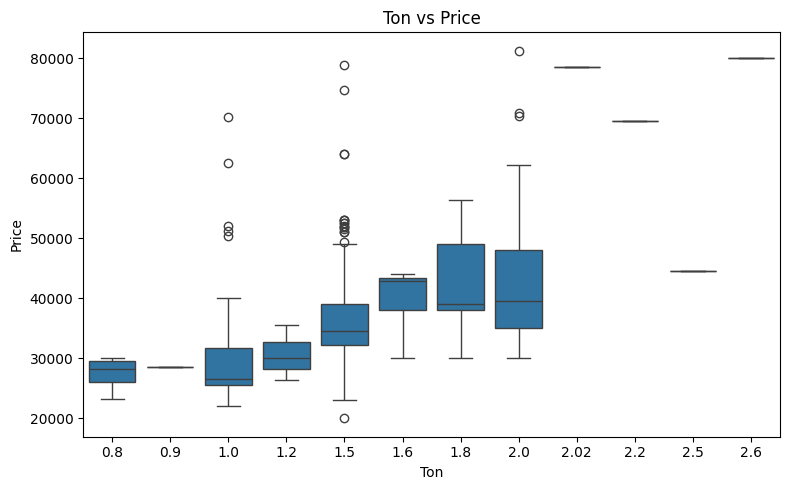

In [50]:
# comparing AC tonnage with price

plt.figure(figsize=(8,5))
sns.boxplot(x="Ton", y="Price", data=df)
plt.title("Ton vs Price")
plt.tight_layout()
plt.show()

### Ton vs Price – Insights :

- As ton increases, price also increases.

- 1.5 ton ACs are the most common and widely available.

- 2 ton ACs show mixed pricing — both budget and premium options exist.









## Star Rating vs Price

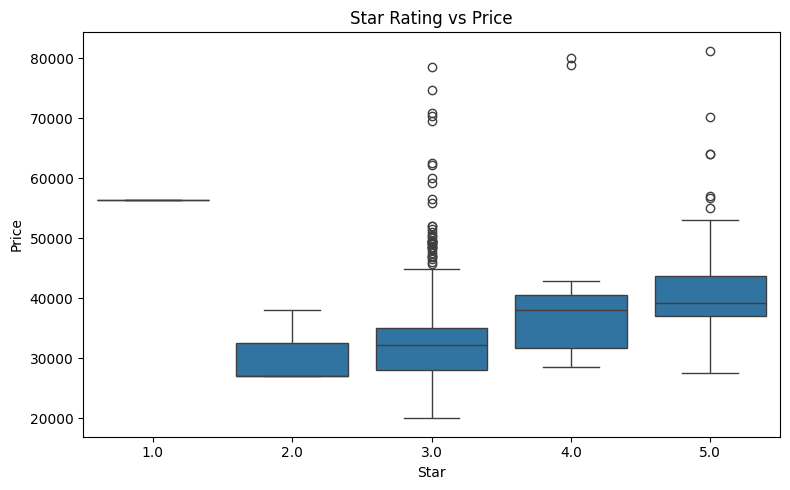

In [51]:
# comparing star ratings with price

plt.figure(figsize=(8,5))
sns.boxplot(x="Star", y="Price", data=df)
plt.title("Star Rating vs Price")
plt.tight_layout()
plt.show()

### Star Rating vs Price – Insights :

- Higher star-rated ACs are generally more expensive.

- 5-star ACs have the widest price variation.

- Energy efficiency usually costs more, but some brands offer it at competitive prices.

### Brand vs Discount

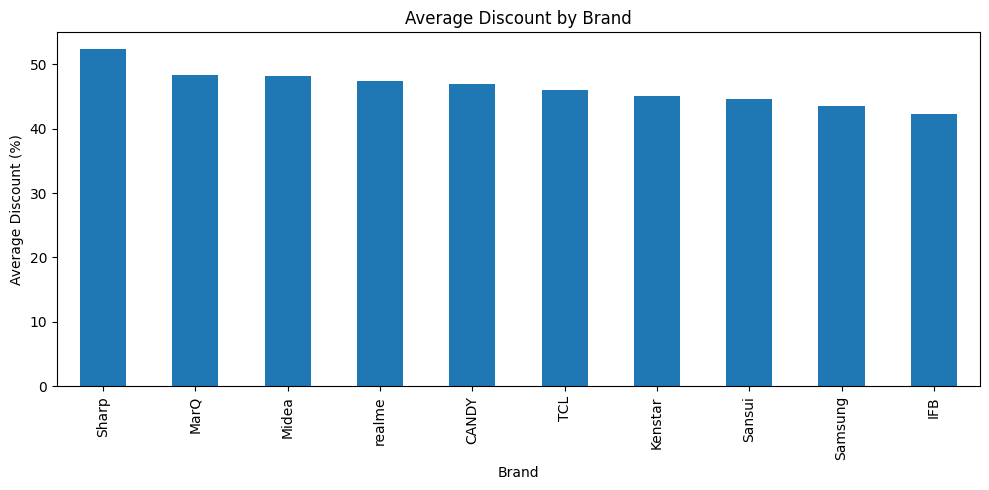

In [ ]:
# which brands offer the highest average discount
brand_discount = df.groupby("Brand")["Discount"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
brand_discount.plot(kind="bar")
plt.title("Average Discount by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Discount (%)")
plt.tight_layout()
plt.show()

### Discount Analysis – Insights:

- Some brands offer significantly higher discounts than others to attract buyers.

- High discounts don't always mean low quality — premium brands also discount 
  heavily during sales to stay competitive.

- Budget brands use discounts as their primary selling strategy on Flipkart.

# Multivariate Analysis

## Correlation Heatmap

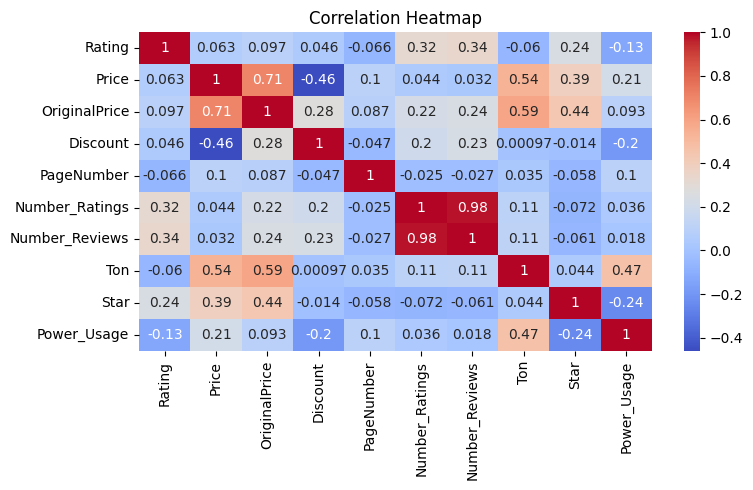

In [52]:
# checking correlation between numerical columns

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Heatmap – Insights:

- Price and Original Price are strongly related — both move together.

- Power usage has a moderate link with both price and tonnage.

- Rating has a weak connection with price — expensive ACs are not always better rated.









## Pairplot Analysis

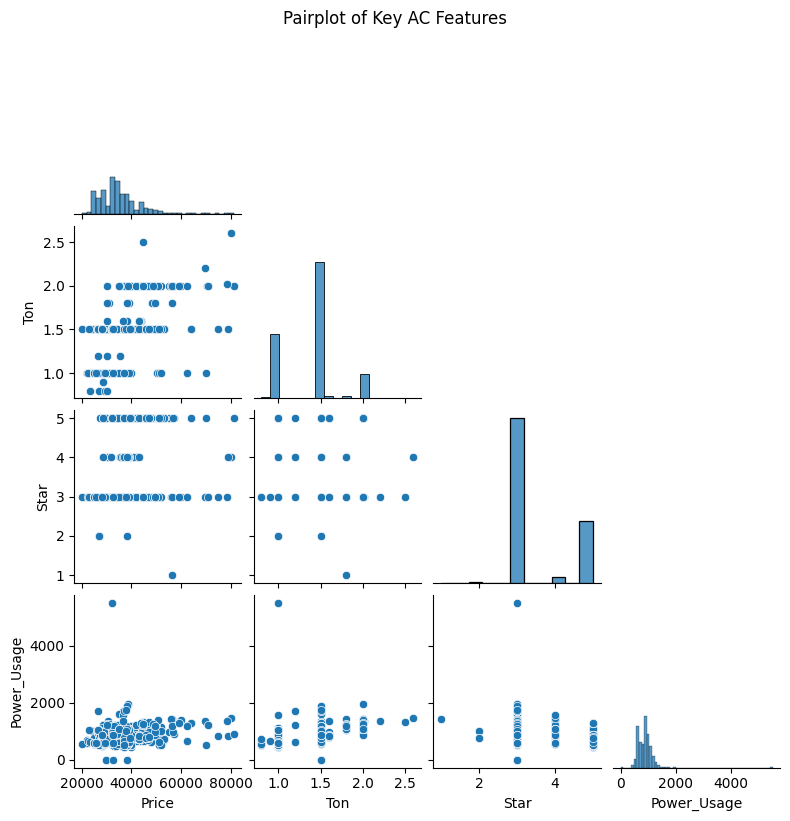

In [55]:
# visualizing relationships between important numerical features

sns.pairplot(df[["Price","Ton","Star","Power_Usage"]],corner=True,height=2)
plt.suptitle("Pairplot of Key AC Features", y=1.02)
plt.show()

### Pairplot – Insights:

- Price and Tonnage show the strongest linear relationship — bigger ACs are clearly more expensive.

- Higher Power Usage is directly linked to higher tonnage, which makes sense technically.

- Star rating shows no strong pattern with price or power usage.

# Key Insights

1. Split ACs dominate Flipkart listings — urban buyers clearly prefer them over Window ACs.

2. Most ACs are priced between ₹25,000 – ₹45,000 — Flipkart targets mid-range buyers.

3. Samsung, Voltas, LG, and Daikin are the most listed brands on the platform.

4. Higher tonnage and star rating directly leads to higher price.

5. Daikin and Hitachi are premium brands while Voltas and LG offer better value.

6. Some brands offer heavy discounts as their primary selling strategy.

7. Price Per Ton analysis reveals which brands offer the best value for money.

8. Power usage increases with tonnage — bigger ACs consume more electricity.

# Conclusion

- This project successfully built an end-to-end pipeline from web scraping to EDA.

- AC product data was collected from Flipkart across 37 pages using BeautifulSoup.

- Data was cleaned, transformed, and enriched through feature engineering techniques.

- Visualizations revealed clear patterns in pricing, brand positioning, and energy efficiency.

- This analysis can help buyers make smarter purchase decisions and help sellers understand market trends.

# Technologies Used

- Python
- BeautifulSoup
- Requests
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Regular Expressions (Regex)
- Jupyter Notebook